# Importing libraries

In [16]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [17]:
# Setting random seed so the splits doesnt change when we re run the cells and randomness in Numpy
np.random.seed(42)

# Data Generation And splitting

In [18]:
# Generating data with true underlying patter and noise 
X = np.linspace(0,1,20).reshape(-1,1)
y = 3 * X.squeeze() + np.random.normal(0,0.3,20)

In [19]:
# split 
X_train, X_test, y_train, y_test = train_test_split(
    X,y , test_size=0.3,random_state=42
)

print("Training samples" , len(X_train))
print("Test samples", len(X_test))

Training samples 14
Test samples 6


# Model training

In [20]:
# simple linear 
lr =LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
train_r2_lr = r2_score(y_train,lr.predict(X_train))
test_r2_lr = r2_score(y_test, lr.predict(X_test))

In [22]:
# Model B - complex polynomial 
poly = PolynomialFeatures(degree=15)
X_train_poly= poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [23]:
pr = LinearRegression()
pr.fit(X_train_poly,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
train_r2_pr =  r2_score(y_train,pr.predict(X_train_poly))
test_r2_pr = r2_score(y_test, pr.predict(X_test_poly))

In [25]:
print("LINEAR MODEL:")
print(f"  Train R²: {train_r2_lr:.3f}")
print(f"  Test R²:  {test_r2_lr:.3f}")

print("\nPOLYNOMIAL MODEL (degree 15):")
print(f"  Train R²: {train_r2_pr:.3f}")
print(f"  Test R²:  {test_r2_pr:.3f}")

LINEAR MODEL:
  Train R²: 0.885
  Test R²:  0.899

POLYNOMIAL MODEL (degree 15):
  Train R²: 1.000
  Test R²:  -214645.091


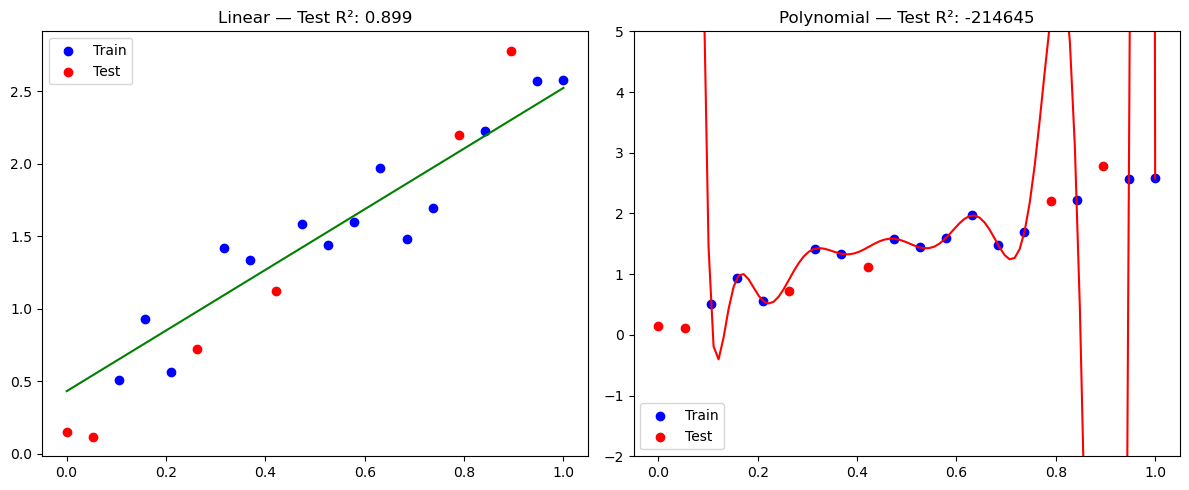

In [26]:
# Visual representation 

X_plot = np.linspace(0, 1, 100).reshape(-1, 1)

plt.figure(figsize=(12, 5))

# Linear model
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color='blue', label='Train')
plt.scatter(X_test, y_test, color='red', label='Test')
plt.plot(X_plot, lr.predict(X_plot), color='green')
plt.title(f'Linear — Test R²: {test_r2_lr:.3f}')
plt.legend()

# Polynomial model
plt.subplot(1, 2, 2)
plt.scatter(X_train, y_train, color='blue', label='Train')
plt.scatter(X_test, y_test, color='red', label='Test')
plt.plot(X_plot, pr.predict(poly.transform(X_plot)), 
         color='red')
plt.ylim(-2, 5)
plt.title(f'Polynomial — Test R²: {test_r2_pr:.0f}')
plt.legend()

plt.tight_layout()
plt.show()

# Ridge Regularization.

In [27]:
from sklearn.linear_model import Ridge

In [28]:
alphas = [0.001,0.01, 0.1 , 1.0, 10.0, 100.0]

In [29]:
print(f"{'Alpha':<10} {'Train R²':<12} {'Test R²'}")
print("-" * 35)

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_poly, y_train)
    
    train_r2 = r2_score(y_train, ridge.predict(X_train_poly))
    test_r2 = r2_score(y_test, ridge.predict(X_test_poly))
    
    print(f"{alpha:<10} {train_r2:<12.3f} {test_r2:.3f}")

Alpha      Train R²     Test R²
-----------------------------------
0.001      0.924        0.912
0.01       0.907        0.891
0.1        0.874        0.824
1.0        0.804        0.639
10.0       0.582        0.278
100.0      0.170        -0.049


In [30]:
from sklearn.model_selection import cross_val_score

print(f"{'Alpha':<10} {'CV Mean R²':<15} {'CV Std'}")
print("-" * 40)

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(
        ridge, X_train_poly, y_train,
        cv=5, scoring='r2'
    )
    print(f"{alpha:<10} {scores.mean():<15.3f} {scores.std():.3f}")

Alpha      CV Mean R²      CV Std
----------------------------------------
0.001      0.210           1.161
0.01       -0.182          1.883
0.1        -0.307          2.003
1.0        0.221           0.713
10.0       0.350           0.288
100.0      0.100           0.099


In [31]:
print("Training samples:", len(X_train))
print("Polynomial features:", X_train_poly.shape[1])

Training samples: 14
Polynomial features: 16


# LAsso 

In [33]:
from sklearn.linear_model import Lasso

In [38]:

print(f"{'Alpha':<10} {'Train R²':<12} {'Test R²':<12} {'Features Used'}")
print("-" * 50)

for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_poly,y_train)

    train_r2 = r2_score(y_train, lasso.predict(X_train_poly))
    test_r2 = r2_score(y_test,lasso.predict(X_test_poly))
    features_used = np.sum(lasso.coef_ != 0)

    print(f"{alpha:<10} {train_r2:<12.3f} {test_r2:<12.3f} {features_used}")

Alpha      Train R²     Test R²      Features Used
--------------------------------------------------
0.001      0.893        0.881        4
0.01       0.886        0.853        2
0.1        0.565        0.324        1
1.0        0.000        -0.146       0
10.0       0.000        -0.146       0
100.0      0.000        -0.146       0
